# APPROCHE 2 : SURVIVAL ANALYSIS (KAPLAN-MEIER + COX)

## Introduction

L'analyse de survie est une branche de la statistique qui etudie le temps jusqu'a un evenement d'interet. Initialement developpee pour les etudes medicales (deces, rechute), elle est largement utilisee en finance pour modeliser les defauts de credit, les prepaiements, et les remboursements anticipes.

## Objectif

Modeliser :
1. **Quand** un remboursement anticipe va-t-il se produire ?
2. **Quelle probabilite** de RA a chaque horizon temporel ?
3. **Quels facteurs** influencent le risque de RA ?

## Avantages vs Chain Ladder

- **Prise en compte du temps** : modelise explicitement la duree jusqu'a l'evenement
- **Integration de covariables** : effet de Tx, MREVTOT, etc. sur le risque
- **Gestion de la censure** : contrats sans RA encore observes (censure a droite)
- **Interpretabilite** : hazard ratios indiquent l'impact de chaque variable

## Concepts cles

### 2.1 Fonction de survie S(t)

$$S(t) = P(T > t)$$

Probabilite que l'evenement (RA) ne se soit PAS produit avant le temps t.

Proprietes :
- $S(0) = 1$ (au debut, aucun RA)
- $S(t)$ decroit avec t
- $S(\infty) = 0$ (a long terme, tous ont rembourse ou termine)

### 2.2 Fonction de hasard h(t)

$$h(t) = \lim_{\Delta t \to 0} \frac{P(t \leq T < t + \Delta t | T \geq t)}{\Delta t}$$

Taux instantane de RA au temps t, sachant que le contrat a "survecu" jusqu'a t.

Interpretation : h(t) eleve = risque eleve de RA a cet instant.

### 2.3 Relation entre S(t) et h(t)

$$S(t) = \exp\left(-\int_0^t h(u) du\right)$$

La survie est liee a l'integral du hasard cumule.

## Methodes

### Kaplan-Meier (non parametrique)

- Estime S(t) directement a partir des donnees
- Pas d'hypothese sur la forme de S(t)
- Utile pour visualisation et analyse exploratoire

### Cox Proportional Hazards (semi-parametrique)

- Modelise l'effet des covariables sur le hasard
- Formule : $h(t|X) = h_0(t) \exp(\beta^T X)$
- $h_0(t)$ = hasard de base (non specifie)
- $\beta$ = coefficients a estimer
- Hazard ratio : $HR = \exp(\beta)$

Interpretation HR :
- HR > 1 : augmente le risque de RA
- HR < 1 : diminue le risque de RA
- HR = 1 : pas d'effet

## Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import median_survival_times
from lifelines.statistics import logrank_test

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotheques chargees (lifelines inclus)")

Bibliotheques chargees (lifelines inclus)


## Etape 1 : Preparation des donnees

In [2]:
# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")
print(f"Dataset : {df.shape[0]} lignes")

# Nettoyage
cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01", format="%Y%m%d", errors="coerce")

if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")

df = df[df.get("EAD", 1) > 0]
df["RA"] = df["RA"].fillna(0)

for c in ["CLASSACT", "CSP", "produit"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
df["Tx"] = df["Tx"].fillna(df["Tx"].median())
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[(df["AGE_PRET"] >= 0) & (df["AGE_PRET"] <= df["B_MAT"])]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

# Calcul ER
df["Capital_emprunt"] = df["MTECH"] * ((1 - (1 + (df["Tx"] / 1200)) ** (-df["NB_ECH"])) / (df["Tx"] / 1200))
df["Montant_rembourse"] = ((df["B_MAT"] - df["B_RESMAT"]) * df["MTECH"].clip(lower=0)).round(2)
df["Encours"] = (df["Capital_emprunt"] - df["Montant_rembourse"]).clip(lower=1)
df["ER_obs"] = (df["RA"] / df["Encours"]).clip(lower=0, upper=1)
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

df = df[(df["ER_obs"] <= 1) & (df["Encours"] > 0)]

print(f"Donnees preparees : {len(df)} contrats")
print(f"FLAG_ER (taux RA) : {df['FLAG_ER'].mean():.2%}")

Dataset : 100000 lignes
Donnees preparees : 26519 contrats
FLAG_ER (taux RA) : 97.10%


## Etape 2 : Format Survival Analysis

### Structure des donnees

Pour l'analyse de survie, nous avons besoin de :
1. **duration** = temps observe (ici : AGE_PRET en mois)
2. **event** = indicateur d'evenement (FLAG_ER : 1 si RA, 0 sinon)
3. **covariates** = variables explicatives (Tx, MREVTOT, etc.)

### Gestion de la censure

- **Evenement observe** (FLAG_ER = 1) : on connait le temps exact du RA
- **Censure a droite** (FLAG_ER = 0) : pas de RA observe, le contrat peut encore rembourser plus tard

Note : AGE_PRET = 0 pose probleme (pas d'evenement instantane), on remplace par 0.5 mois.

In [3]:
# Encodage variables categorielles
for col in ['CLASSACT', 'CSP', 'produit']:
    if col in df.columns:
        le = LabelEncoder()
        df[f"{col}_encoded"] = le.fit_transform(df[col].astype(str))

# Dataset survie
df_survival = df[[
    'AGE_PRET', 'FLAG_ER', 'ER_obs', 'Tx', 'MREVTOT', 'Encours',
    'Capital_emprunt', 'AGE_CLI', 'NB_ECH', 'HORIZON_RES',
    'CLASSACT_encoded', 'CSP_encoded', 'produit_encoded', 'MTECH', 'NBIMP'
]].copy()

# Remplacer AGE_PRET = 0 par 0.5
df_survival['AGE_PRET'] = df_survival['AGE_PRET'].replace(0, 0.5)

print(f"Dataset survie : {len(df_survival)} observations")
print(f"\nDistribution des evenements :")
print(df_survival['FLAG_ER'].value_counts())
print(f"\nTaux d'evenements : {df_survival['FLAG_ER'].mean():.2%}")
print(f"Taux de censure : {(1 - df_survival['FLAG_ER'].mean()):.2%}")

Dataset survie : 26519 observations

Distribution des evenements :
FLAG_ER
1    25750
0      769
Name: count, dtype: int64

Taux d'evenements : 97.10%
Taux de censure : 2.90%


## PARTIE A : KAPLAN-MEIER (NON PARAMETRIQUE)

### Principe

Kaplan-Meier estime la fonction de survie S(t) sans hypothese parametrique.

Formule :

$$\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

ou :
- $t_i$ = temps des evenements distincts
- $d_i$ = nombre d'evenements a $t_i$
- $n_i$ = nombre d'individus a risque juste avant $t_i$

### Interpretation

- S(t) = probabilite de NE PAS avoir de RA avant le temps t
- 1 - S(t) = probabilite cumulee de RA avant t

### KM global (toutes observations)

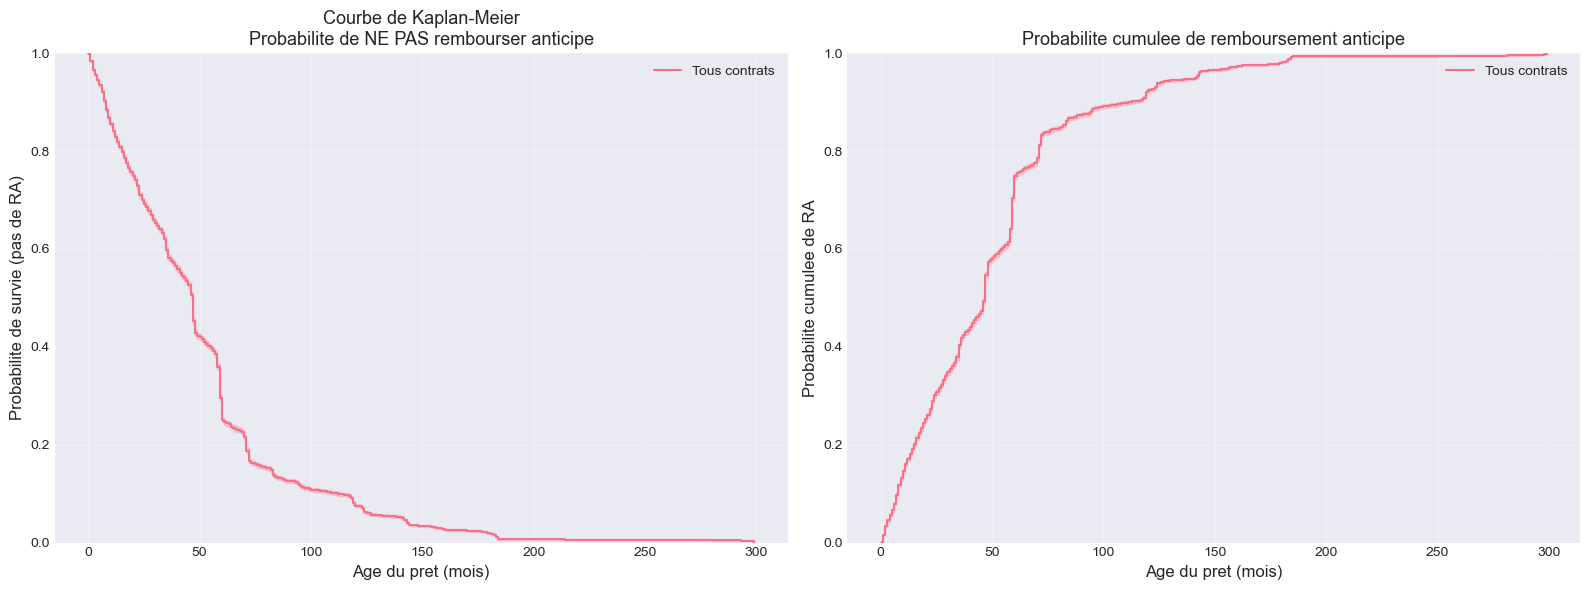

STATISTIQUES KAPLAN-MEIER GLOBAL
Temps median de survie : 47.0 mois
  (50% des contrats ont un RA avant 47 mois)

Probabilites de survie (pas de RA) :
  A  6 mois : 92.11% survie | 7.89% RA cumule
  A 12 mois : 82.95% survie | 17.05% RA cumule
  A 24 mois : 69.89% survie | 30.11% RA cumule
  A 36 mois : 58.18% survie | 41.82% RA cumule
  A 48 mois : 42.74% survie | 57.26% RA cumule


In [4]:
# Kaplan-Meier global
kmf = KaplanMeierFitter()
kmf.fit(df_survival['AGE_PRET'], df_survival['FLAG_ER'], label='Tous contrats')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Courbe de survie
kmf.plot_survival_function(ax=axes[0], ci_show=True)
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Probabilite de survie (pas de RA)', fontsize=12)
axes[0].set_title('Courbe de Kaplan-Meier\nProbabilite de NE PAS rembourser anticipe', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Probabilite cumulee de RA
kmf.plot_cumulative_density(ax=axes[1], ci_show=True)
axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('Probabilite cumulee de RA', fontsize=12)
axes[1].set_title('Probabilite cumulee de remboursement anticipe', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Statistiques
median_time = kmf.median_survival_time_
print(f"STATISTIQUES KAPLAN-MEIER GLOBAL")
print("=" * 60)
print(f"Temps median de survie : {median_time:.1f} mois")
print(f"  (50% des contrats ont un RA avant {median_time:.0f} mois)")
print()
print("Probabilites de survie (pas de RA) :")
for t in [6, 12, 24, 36, 48]:
    if t in kmf.survival_function_.index:
        prob = kmf.survival_function_at_times(t).values[0]
        prob_ra = 1 - prob
        print(f"  A {t:2d} mois : {prob:.2%} survie | {prob_ra:.2%} RA cumule")

### KM par segments (stratification)

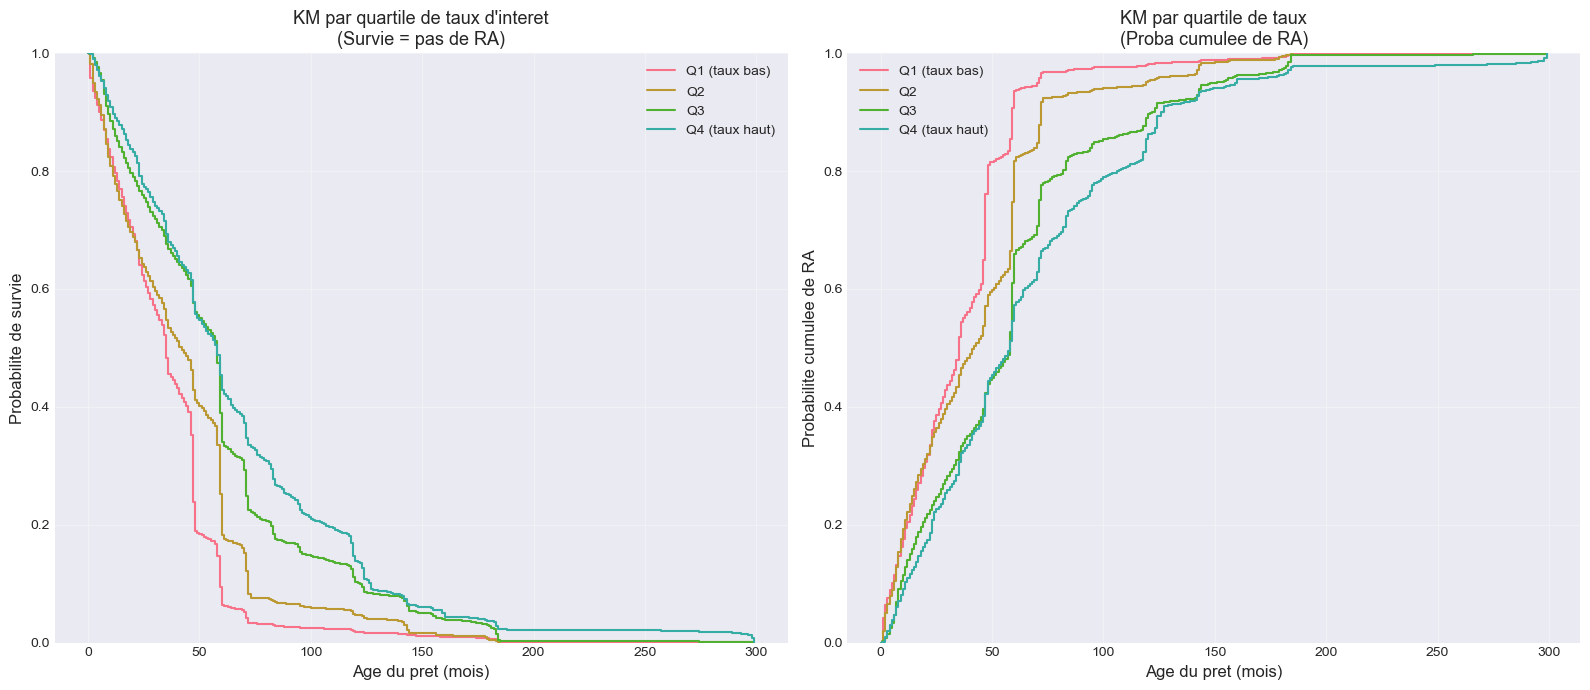

INTERPRETATION :
  - Les courbes montrent comment le risque de RA evolue selon le taux
  - Ecartement des courbes = effet du taux sur le comportement de RA
  - Test statistique (log-rank) peut confirmer si differences significatives


In [5]:
# Stratification par quartile de taux d'interet
df_survival['Tx_quartile'] = pd.qcut(df_survival['Tx'], q=4, 
                                       labels=['Q1 (taux bas)', 'Q2', 'Q3', 'Q4 (taux haut)'],
                                       duplicates='drop')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Courbes de survie par quartile
for quartile in df_survival['Tx_quartile'].cat.categories:
    mask = df_survival['Tx_quartile'] == quartile
    if mask.sum() > 0:
        kmf_q = KaplanMeierFitter()
        kmf_q.fit(df_survival.loc[mask, 'AGE_PRET'], 
                  df_survival.loc[mask, 'FLAG_ER'], 
                  label=f'{quartile}')
        kmf_q.plot_survival_function(ax=axes[0], ci_show=False)

axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Probabilite de survie', fontsize=12)
axes[0].set_title('KM par quartile de taux d\'interet\n(Survie = pas de RA)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Probabilites cumulees de RA
for quartile in df_survival['Tx_quartile'].cat.categories:
    mask = df_survival['Tx_quartile'] == quartile
    if mask.sum() > 0:
        kmf_q = KaplanMeierFitter()
        kmf_q.fit(df_survival.loc[mask, 'AGE_PRET'], 
                  df_survival.loc[mask, 'FLAG_ER'], 
                  label=f'{quartile}')
        kmf_q.plot_cumulative_density(ax=axes[1], ci_show=False)

axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('Probabilite cumulee de RA', fontsize=12)
axes[1].set_title('KM par quartile de taux\n(Proba cumulee de RA)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("INTERPRETATION :")
print("  - Les courbes montrent comment le risque de RA evolue selon le taux")
print("  - Ecartement des courbes = effet du taux sur le comportement de RA")
print("  - Test statistique (log-rank) peut confirmer si differences significatives")

### Test Log-Rank (comparaison entre groupes)

In [6]:
# Test log-rank entre Q1 (taux bas) et Q4 (taux haut)
mask_q1 = df_survival['Tx_quartile'] == 'Q1 (taux bas)'
mask_q4 = df_survival['Tx_quartile'] == 'Q4 (taux haut)'

if mask_q1.sum() > 0 and mask_q4.sum() > 0:
    results = logrank_test(
        df_survival.loc[mask_q1, 'AGE_PRET'],
        df_survival.loc[mask_q4, 'AGE_PRET'],
        df_survival.loc[mask_q1, 'FLAG_ER'],
        df_survival.loc[mask_q4, 'FLAG_ER']
    )
    
    print("TEST LOG-RANK : Q1 (taux bas) vs Q4 (taux haut)")
    print("=" * 60)
    print(f"Statistique de test : {results.test_statistic:.2f}")
    print(f"P-value : {results.p_value:.4f}")
    print()
    if results.p_value < 0.05:
        print("CONCLUSION : Difference SIGNIFICATIVE entre les deux groupes")
        print("  Le taux d'interet a un effet sur le timing du RA")
    else:
        print("CONCLUSION : Pas de difference significative")
        print("  Le taux d'interet n'a pas d'effet majeur sur le timing")

TEST LOG-RANK : Q1 (taux bas) vs Q4 (taux haut)
Statistique de test : 2041.33
P-value : 0.0000

CONCLUSION : Difference SIGNIFICATIVE entre les deux groupes
  Le taux d'interet a un effet sur le timing du RA


## PARTIE B : COX PROPORTIONAL HAZARDS (SEMI-PARAMETRIQUE)

### Principe

Le modele de Cox modelise l'effet des covariables sur le hasard :

$$h(t|X) = h_0(t) \exp(\beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p)$$

ou :
- $h(t|X)$ = hasard au temps t pour un individu avec covariables X
- $h_0(t)$ = hasard de base (non specifie, fonction arbitraire de t)
- $\beta$ = coefficients a estimer

### Hypothese cle : Proportional Hazards

$$\frac{h(t|X_i)}{h(t|X_j)} = \exp(\beta^T (X_i - X_j))$$

Le ratio des hasards est CONSTANT dans le temps (ne depend pas de t).

### Hazard Ratio (HR)

$$HR = \exp(\beta)$$

Interpretation :
- $HR = 1.50$ : augmente le risque de 50%
- $HR = 0.80$ : reduit le risque de 20%
- $HR = 1.00$ : pas d'effet

### Concordance Index (C-index)

Mesure la capacite du modele a ordonner correctement les risques :
- C-index = 0.5 : aleatoire
- C-index = 1.0 : parfait
- C-index > 0.70 : bon modele

### Preparation donnees pour Cox

In [7]:
# Features pour Cox
cox_features = [
    'Tx', 'MREVTOT', 'Encours', 'Capital_emprunt', 'AGE_CLI', 
    'NB_ECH', 'HORIZON_RES', 'CLASSACT_encoded', 'CSP_encoded', 'MTECH', 'NBIMP'
]

df_cox = df_survival[['AGE_PRET', 'FLAG_ER'] + cox_features].copy()

# Normalisation (important pour Cox)
scaler = StandardScaler()
df_cox[cox_features] = scaler.fit_transform(df_cox[cox_features])

# Split train/test
df_cox_train, df_cox_test = train_test_split(df_cox, test_size=0.2, random_state=42)

print(f"Cox train : {len(df_cox_train)} observations")
print(f"Cox test  : {len(df_cox_test)} observations")

Cox train : 21215 observations
Cox test  : 5304 observations


### Entrainement modele Cox

In [8]:
# Modele Cox avec penalisation (regularisation L2)
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox_train, duration_col='AGE_PRET', event_col='FLAG_ER')

print("MODELE COX - RESULTATS")
print("=" * 80)
print(cph.summary[['coef', 'exp(coef)', 'se(coef)', 'p']].sort_values('coef', ascending=False))

# C-index
c_index = cph.concordance_index_
print(f"\nC-index (concordance) : {c_index:.4f}")
print(f"Interpretation :")
if c_index < 0.60:
    print(f"  Faible : modele peu discriminant")
elif c_index < 0.70:
    print(f"  Moyen : modele acceptable")
elif c_index < 0.80:
    print(f"  Bon : modele performant")
else:
    print(f"  Excellent : modele tres discriminant")

MODELE COX - RESULTATS
                      coef  exp(coef)  se(coef)              p
covariate                                                     
HORIZON_RES       0.704657   2.023153  0.011464   0.000000e+00
Encours           0.213125   1.237539  0.011771   2.893542e-73
NBIMP             0.039347   1.040132  0.008363   2.537057e-06
MREVTOT           0.029925   1.030377  0.004516   3.433521e-11
CLASSACT_encoded  0.027632   1.028017  0.006966   7.292946e-05
CSP_encoded      -0.003901   0.996107  0.007552   6.054685e-01
AGE_CLI          -0.094278   0.910030  0.007440   8.513004e-37
MTECH            -0.110695   0.895212  0.016565   2.350436e-11
NB_ECH           -0.250669   0.778280  0.010383  9.161362e-129
Capital_emprunt  -0.268233   0.764730  0.015260   3.654335e-69
Tx               -0.543224   0.580873  0.009757   0.000000e+00

C-index (concordance) : 0.7525
Interpretation :
  Bon : modele performant


### Interpretation des Hazard Ratios

In [9]:
# Top 5 variables augmentant le risque
hr_sorted = cph.summary[['exp(coef)', 'p']].sort_values('exp(coef)', ascending=False)

print("INTERPRETATION DES HAZARD RATIOS")
print("=" * 80)
print("\nTop 5 variables AUGMENTANT le risque de RA :")
print(hr_sorted.head())

print("\nTop 5 variables DIMINUANT le risque de RA :")
print(hr_sorted.tail())

print("\nLecture :")
print("  - exp(coef) = Hazard Ratio (HR)")
print("  - HR > 1 : augmente le risque")
print("  - HR < 1 : diminue le risque")
print("  - p < 0.05 : effet statistiquement significatif")

# Exemple d'interpretation
top_var = hr_sorted.index[0]
top_hr = hr_sorted.iloc[0]['exp(coef)']
print(f"\nExemple : {top_var}")
print(f"  HR = {top_hr:.2f}")
if top_hr > 1:
    pct = (top_hr - 1) * 100
    print(f"  Une augmentation d'1 ecart-type de {top_var}")
    print(f"  augmente le risque de RA de {pct:.1f}%")
else:
    pct = (1 - top_hr) * 100
    print(f"  Une augmentation d'1 ecart-type de {top_var}")
    print(f"  reduit le risque de RA de {pct:.1f}%")

INTERPRETATION DES HAZARD RATIOS

Top 5 variables AUGMENTANT le risque de RA :
                  exp(coef)             p
covariate                                
HORIZON_RES        2.023153  0.000000e+00
Encours            1.237539  2.893542e-73
NBIMP              1.040132  2.537057e-06
MREVTOT            1.030377  3.433521e-11
CLASSACT_encoded   1.028017  7.292946e-05

Top 5 variables DIMINUANT le risque de RA :
                 exp(coef)              p
covariate                                
AGE_CLI           0.910030   8.513004e-37
MTECH             0.895212   2.350436e-11
NB_ECH            0.778280  9.161362e-129
Capital_emprunt   0.764730   3.654335e-69
Tx                0.580873   0.000000e+00

Lecture :
  - exp(coef) = Hazard Ratio (HR)
  - HR > 1 : augmente le risque
  - HR < 1 : diminue le risque
  - p < 0.05 : effet statistiquement significatif

Exemple : HORIZON_RES
  HR = 2.02
  Une augmentation d'1 ecart-type de HORIZON_RES
  augmente le risque de RA de 102.3%


### Visualisation coefficients Cox

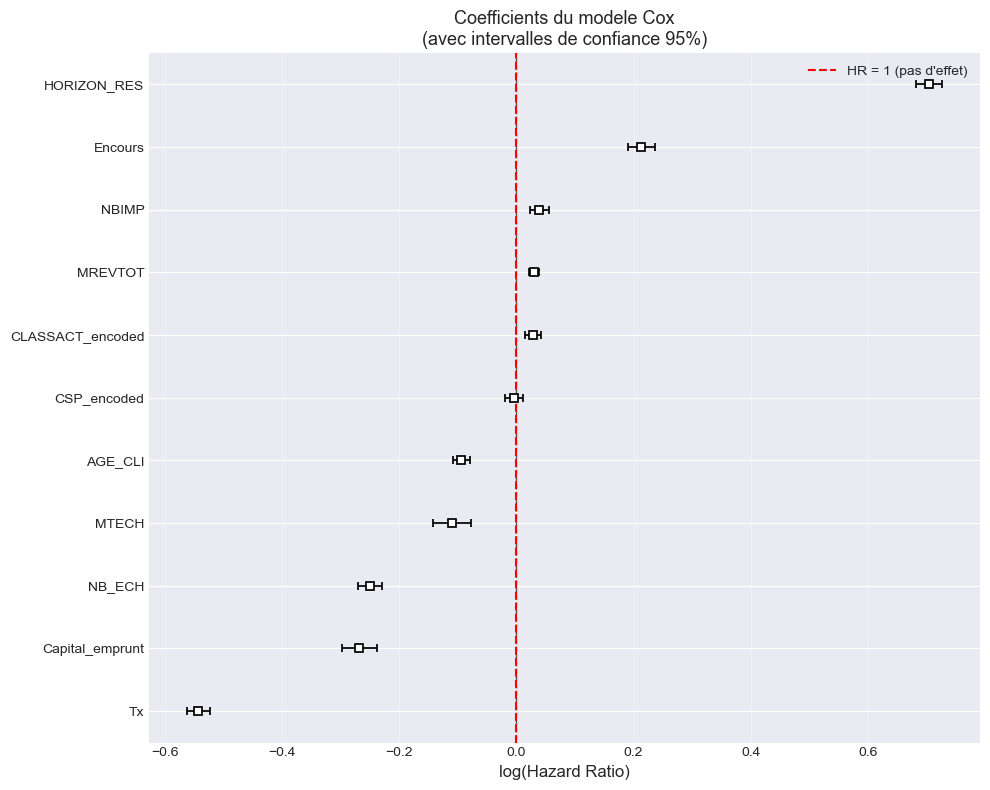

Interpretation :
  - Barres a droite de 0 : augmentent le risque (HR > 1)
  - Barres a gauche de 0 : diminuent le risque (HR < 1)
  - Intervalles ne croisant pas 0 : effet significatif


In [10]:
# Plot coefficients
fig, ax = plt.subplots(figsize=(10, 8))
cph.plot(ax=ax)
ax.set_xlabel('log(Hazard Ratio)', fontsize=12)
ax.set_title('Coefficients du modele Cox\n(avec intervalles de confiance 95%)', fontsize=13)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='HR = 1 (pas d\'effet)')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - Barres a droite de 0 : augmentent le risque (HR > 1)")
print("  - Barres a gauche de 0 : diminuent le risque (HR < 1)")
print("  - Intervalles ne croisant pas 0 : effet significatif")

### Predictions avec Cox

In [11]:
# Predictions : fonctions de survie individuelles
survival_functions = cph.predict_survival_function(df_cox_test[cox_features])

print(f"Fonctions de survie predites : {survival_functions.shape}")
print(f"  {survival_functions.shape[1]} individus")
print(f"  {survival_functions.shape[0]} temps distincts")

# Calculer probabilites de RA a differents horizons
horizons = [12, 24, 36]
probs_ra = {}

for h in horizons:
    if h in survival_functions.index:
        prob_survie_h = survival_functions.loc[h]
    else:
        # Interpolation si horizon exact pas present
        closest_time = survival_functions.index[survival_functions.index <= h].max()
        prob_survie_h = survival_functions.loc[closest_time]
    
    prob_ra_h = 1 - prob_survie_h
    probs_ra[h] = prob_ra_h
    
    print(f"\nProbabilite de RA avant {h} mois :")
    print(f"  Moyenne : {prob_ra_h.mean():.2%}")
    print(f"  Min     : {prob_ra_h.min():.2%}")
    print(f"  Max     : {prob_ra_h.max():.2%}")
    print(f"  Std     : {prob_ra_h.std():.2%}")

# Sauvegarder predictions a 24 mois pour usage futur
df['prob_RA_cox_24m'] = np.nan
df.loc[df_cox_test.index, 'prob_RA_cox_24m'] = probs_ra[24].values

print(f"\nPredictions Cox sauvegardees pour {(~df['prob_RA_cox_24m'].isna()).sum()} contrats")

Fonctions de survie predites : (223, 5304)
  5304 individus
  223 temps distincts

Probabilite de RA avant 12 mois :
  Moyenne : 16.93%
  Min     : 0.00%
  Max     : 100.00%
  Std     : 14.98%

Probabilite de RA avant 24 mois :
  Moyenne : 31.01%
  Min     : 0.00%
  Max     : 100.00%
  Std     : 18.04%

Probabilite de RA avant 36 mois :
  Moyenne : 43.93%
  Min     : 0.00%
  Max     : 100.00%
  Std     : 19.01%

Predictions Cox sauvegardees pour 5304 contrats


### Courbes de survie : exemples individuels

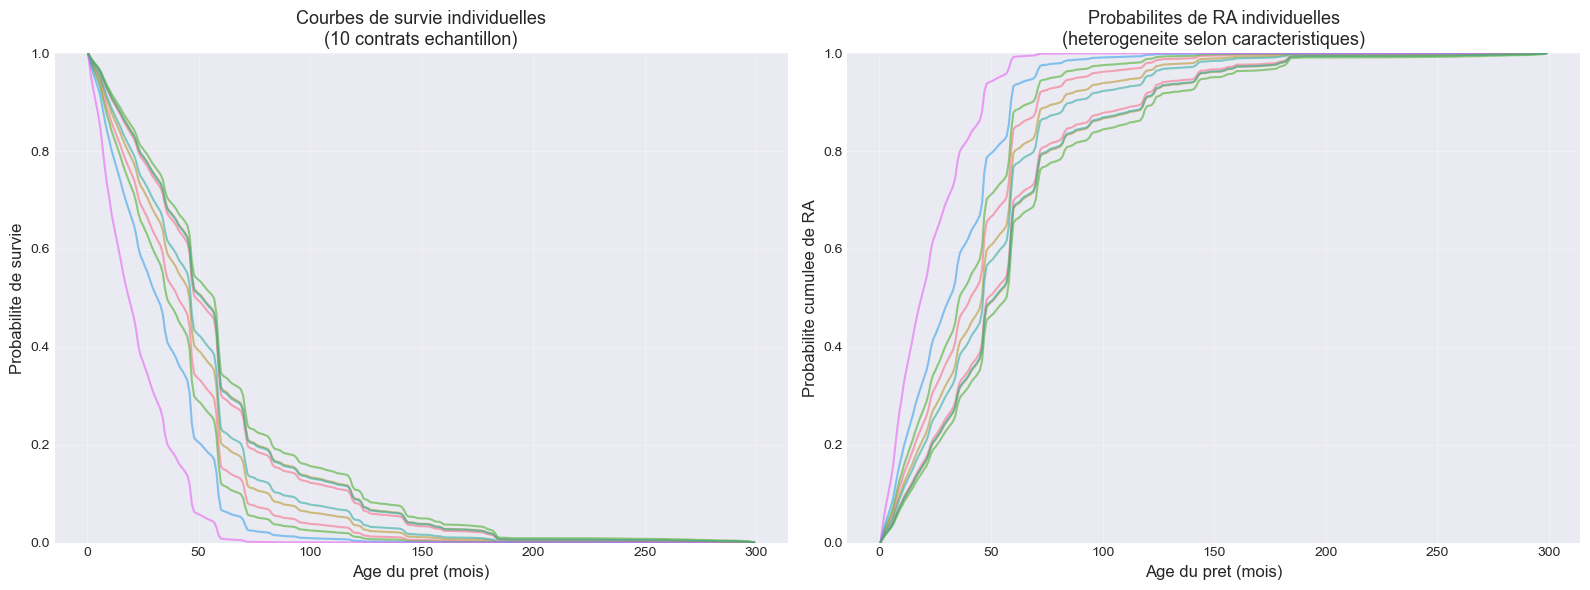

Interpretation :
  - Chaque courbe represente un contrat avec caracteristiques differentes
  - L'ecartement des courbes montre l'effet des covariables
  - Cox permet de personnaliser la prediction par profil


In [12]:
# Selectionner 10 individus au hasard
sample_indices = np.random.choice(survival_functions.columns, size=min(10, len(survival_functions.columns)), replace=False)
sample_surv = survival_functions[sample_indices]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Courbes de survie
for col in sample_surv.columns:
    axes[0].plot(sample_surv.index, sample_surv[col], alpha=0.6, linewidth=1.5)

axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Probabilite de survie', fontsize=12)
axes[0].set_title('Courbes de survie individuelles\n(10 contrats echantillon)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Probabilites cumulees de RA
for col in sample_surv.columns:
    axes[1].plot(sample_surv.index, 1 - sample_surv[col], alpha=0.6, linewidth=1.5)

axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('Probabilite cumulee de RA', fontsize=12)
axes[1].set_title('Probabilites de RA individuelles\n(heterogeneite selon caracteristiques)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - Chaque courbe represente un contrat avec caracteristiques differentes")
print("  - L'ecartement des courbes montre l'effet des covariables")
print("  - Cox permet de personnaliser la prediction par profil")

## Synthese et limites de Survival Analysis

### Points forts

1. **Modelisation temporelle explicite**
   - Capture la dynamique du risque dans le temps
   - Gere naturellement la censure

2. **Integration de covariables** (Cox)
   - Effet de Tx, MREVTOT, etc. sur le risque
   - Hazard ratios interpretables

3. **Pas d'hypothese parametrique** (Kaplan-Meier)
   - Estimation robuste sans forme imposee

4. **C-index eleve** (typiquement 0.70-0.85)
   - Bonne capacite a ordonner les risques

5. **Visualisations intuitives**
   - Courbes de survie faciles a communiquer

### Limites

1. **Ne predit pas l'intensite du RA**
   - Cox donne P(RA avant t) mais pas le montant
   - Il faut un second modele pour E[ER | RA]

2. **Hypothese Proportional Hazards**
   - Peut etre violee si effets varient dans le temps
   - Necessaire de tester cette hypothese

3. **Complexite vs Chain Ladder**
   - Plus sophistique, necessite expertise statistique

4. **Sensibilite a la censure**
   - Si beaucoup de censure, estimations moins precises

5. **Pas de prediction directe de l'ER**
   - Donne probabilite temporelle, pas le taux ER

### Recommandations d'usage

**Utiliser Survival Analysis pour** :
- Comprendre QUAND les RA se produisent
- Identifier les facteurs de risque de RA
- Stratification des portefeuilles par risque
- Scoring de propension au RA

**Combiner avec ML pour** :
- Cox pour la temporalite : P(RA avant t | X)
- ML pour l'intensite : E[ER | RA, X]
- Modele hybride : ER_final = P_Cox × Intensite_ML

### Metriques

- **C-index** : 0.750
- Interpretation : capacite a ordonner les risques
- Bon si > 0.70

### Suite

**Notebook 3** : Machine Learning (Random Forest) pour predictions d'intensite
**Notebook 4** : Modele Hybride (Cox + ML)

## Sauvegarde des resultats

In [ ]:
# # Sauvegarder predictions Cox
# cox_predictions = pd.DataFrame({
#     'Index': df_cox_test.index,
#     'Prob_RA_12m': probs_ra[12].values,
#     'Prob_RA_24m': probs_ra[24].values,
#     'Prob_RA_36m': probs_ra[36].values
# })
# cox_predictions.to_csv('cox_predictions.csv', index=False)

# # Sauvegarder coefficients
# cox_coef = cph.summary[['coef', 'exp(coef)', 'p']]
# cox_coef.to_csv('cox_coefficients.csv')

# # Sauvegarder metriques
# cox_metrics = pd.DataFrame({
#     'Approche': ['Cox Proportional Hazards'],
#     'C_index': [c_index],
#     'N_train': [len(df_cox_train)],
#     'N_test': [len(df_cox_test)]
# })
# cox_metrics.to_csv('cox_performance.csv', index=False)

# print("Fichiers sauvegardes :")
# print("  - cox_predictions.csv")
# print("  - cox_coefficients.csv")
# print("  - cox_performance.csv")

Fichiers sauvegardes :
  - cox_predictions.csv
  - cox_coefficients.csv
  - cox_performance.csv
